# 03 — Grad-CAM explanations

Visualize which regions the model uses for Normal vs Pneumonia predictions.

Requires a trained checkpoint at `artifacts/best.pt`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from IPython.display import Image, display

from cxr_pneumonia.config import load_config
from cxr_pneumonia.explain import explain

cfg = load_config(ROOT / "configs" / "default.yaml")
# YAML paths are relative to the project root, not the notebooks/ folder
cfg.data_dir = str((ROOT / cfg.data_dir).resolve())
cfg.artifacts_dir = str((ROOT / cfg.artifacts_dir).resolve())
ckpt = cfg.artifacts_path / "best.pt"
assert ckpt.exists(), f"Missing checkpoint: {ckpt}. Train first (notebook 02 or scripts/train.py)."
print("data_dir:", cfg.data_path)
print("checkpoint:", ckpt)

data_dir: /Users/htethtetoo/medical-image-analysis/data/chest_xray
checkpoint: /Users/htethtetoo/medical-image-analysis/artifacts/best.pt


In [2]:
# Fresh folder so old runs don't mix in; samples are interleaved NORMAL / PNEUMONIA
out_dir = cfg.artifacts_path / "gradcam_notebook"
if out_dir.exists():
    for old in out_dir.glob("*.png"):
        old.unlink()
out_dir = explain(cfg, ckpt, split="test", n=8, out_dir=out_dir)
out_dir
list(sorted(p.name for p in out_dir.glob("*.png")))

Saved 8 Grad-CAM figures → /Users/htethtetoo/medical-image-analysis/artifacts/gradcam_notebook


['gradcam_test_00_true-NORMAL_pred-PNEUMONIA.png',
 'gradcam_test_01_true-PNEUMONIA_pred-PNEUMONIA.png',
 'gradcam_test_02_true-NORMAL_pred-NORMAL.png',
 'gradcam_test_03_true-PNEUMONIA_pred-PNEUMONIA.png',
 'gradcam_test_04_true-NORMAL_pred-NORMAL.png',
 'gradcam_test_05_true-PNEUMONIA_pred-PNEUMONIA.png',
 'gradcam_test_06_true-NORMAL_pred-PNEUMONIA.png',
 'gradcam_test_07_true-PNEUMONIA_pred-PNEUMONIA.png']

=== NORMAL examples ===
gradcam_test_00_true-NORMAL_pred-PNEUMONIA.png


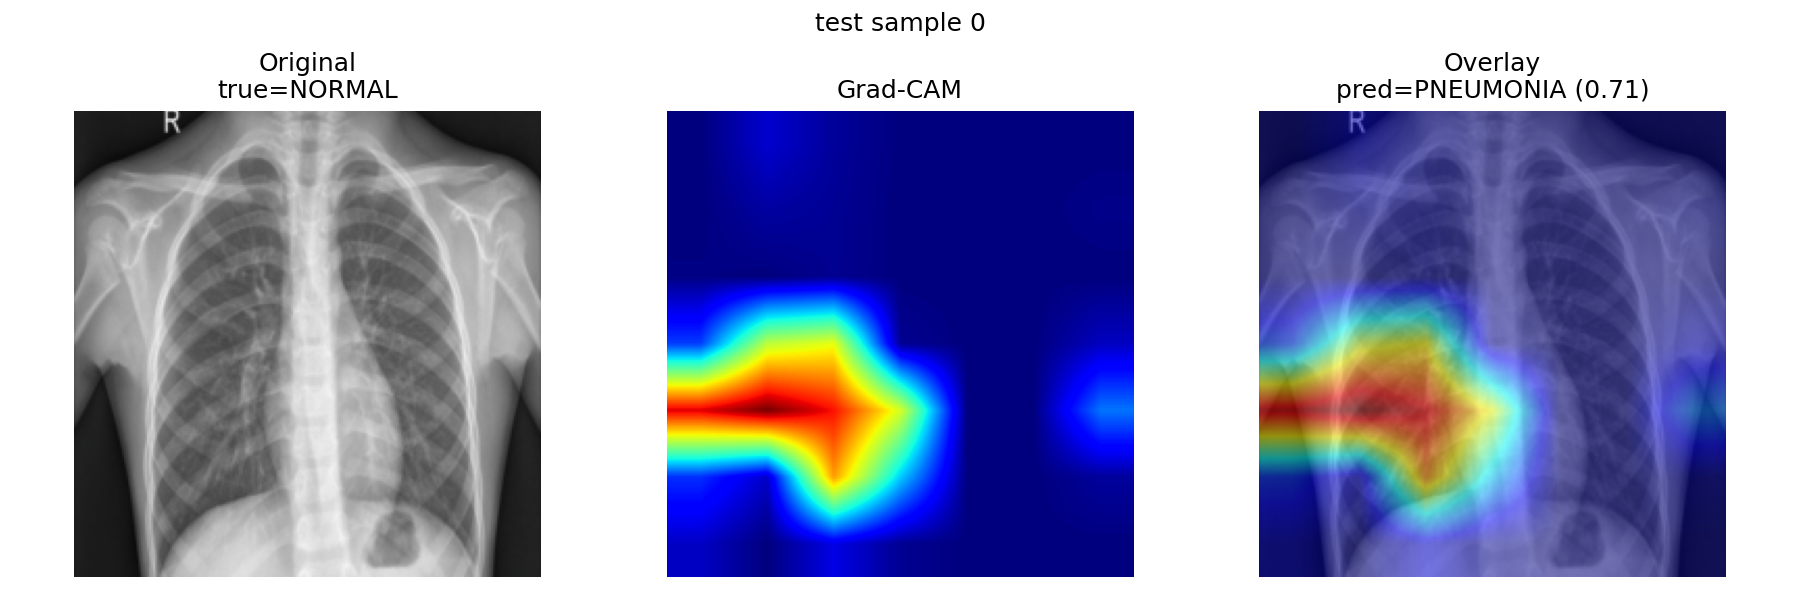

gradcam_test_02_true-NORMAL_pred-NORMAL.png


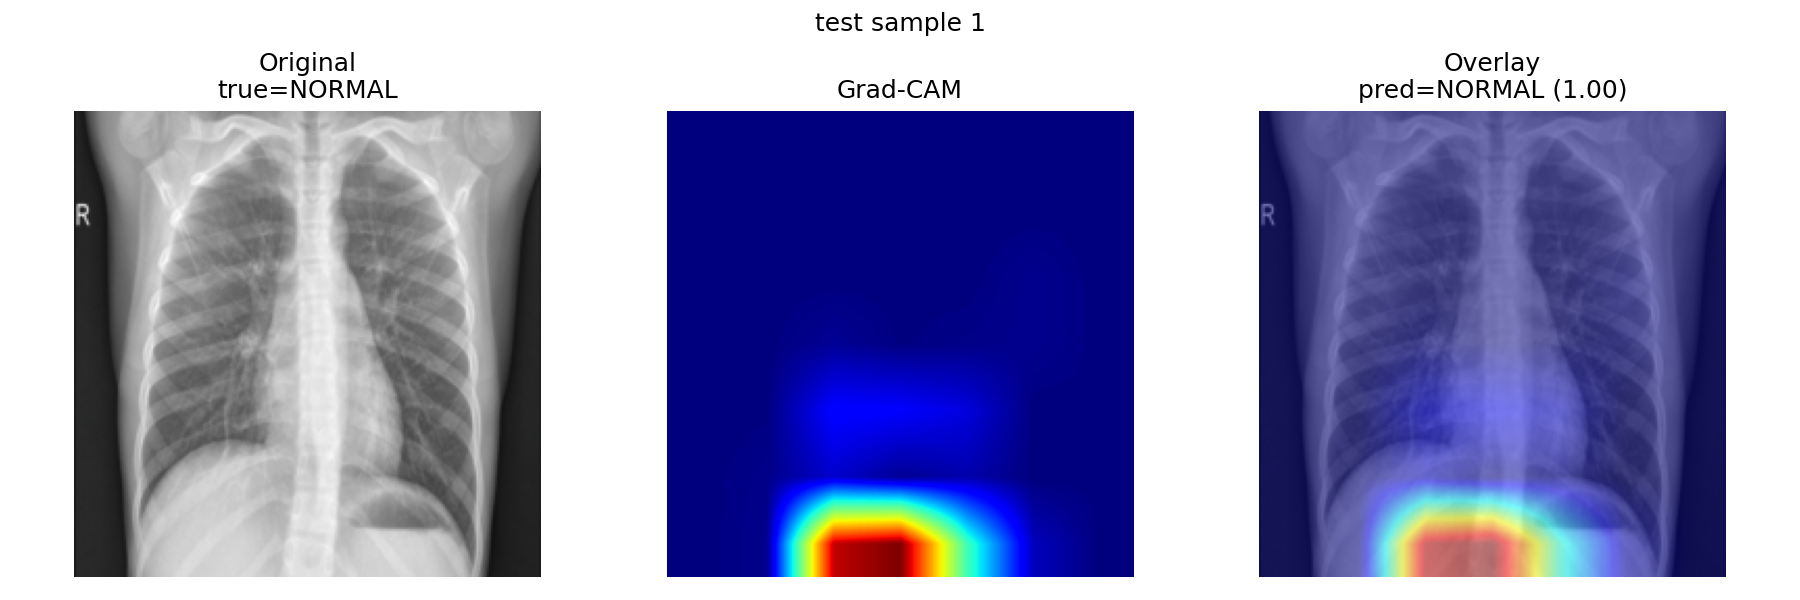

gradcam_test_04_true-NORMAL_pred-NORMAL.png


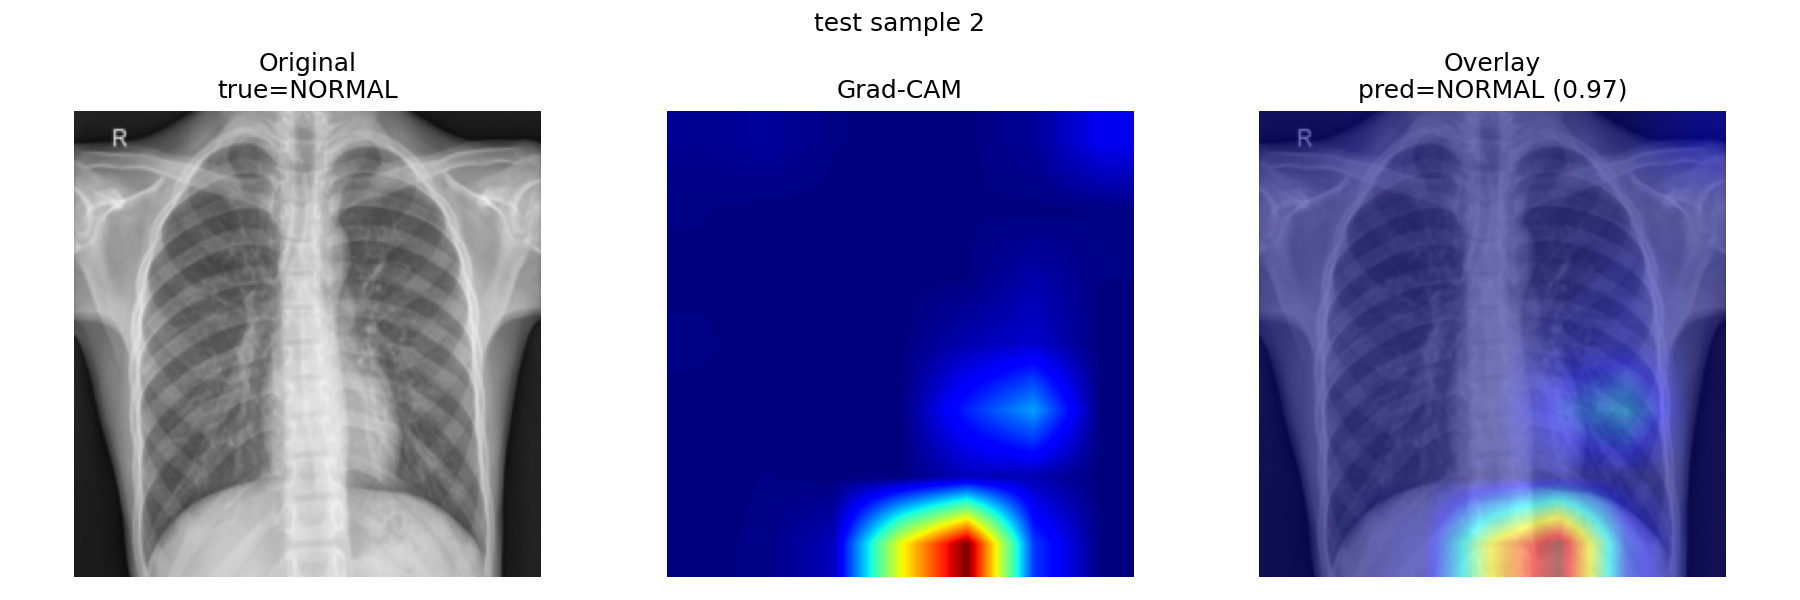

=== PNEUMONIA examples ===
gradcam_test_01_true-PNEUMONIA_pred-PNEUMONIA.png


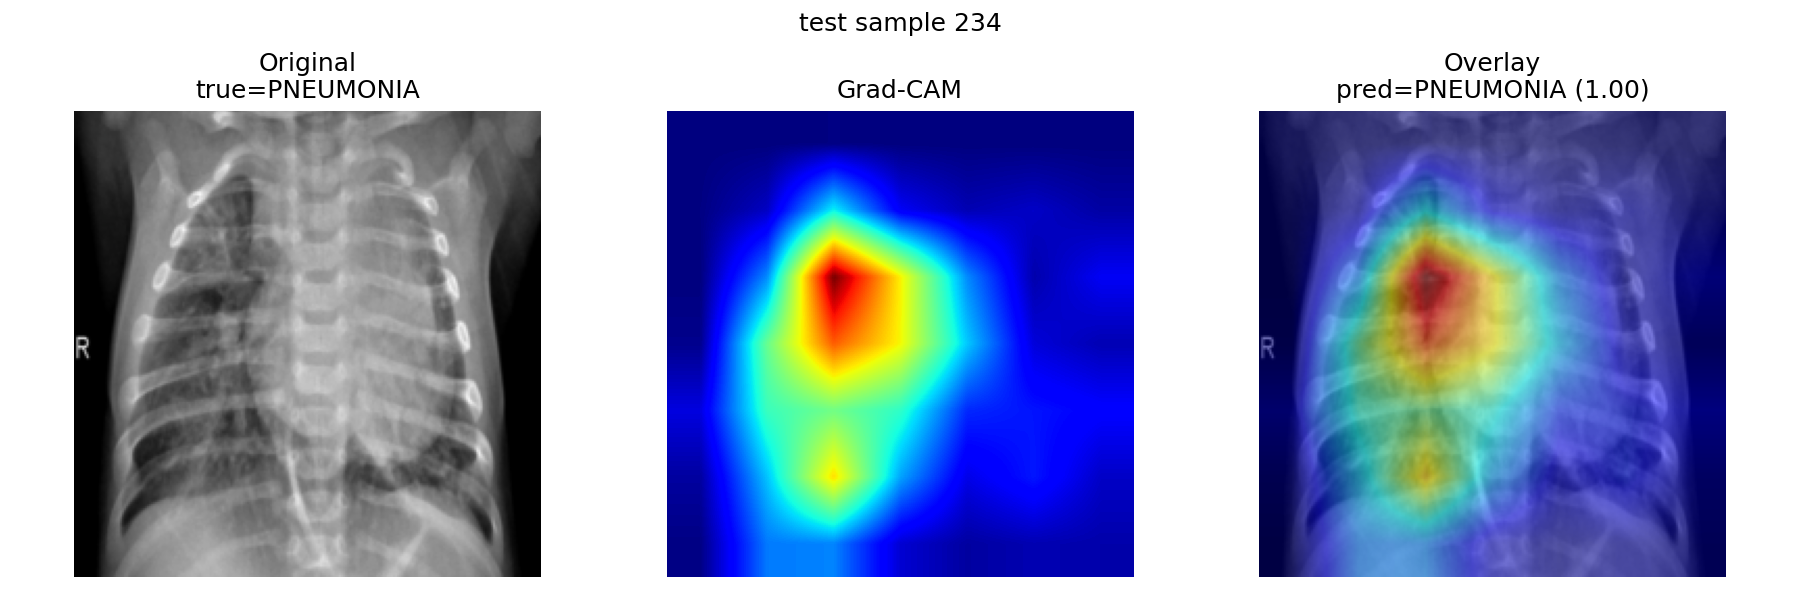

gradcam_test_03_true-PNEUMONIA_pred-PNEUMONIA.png


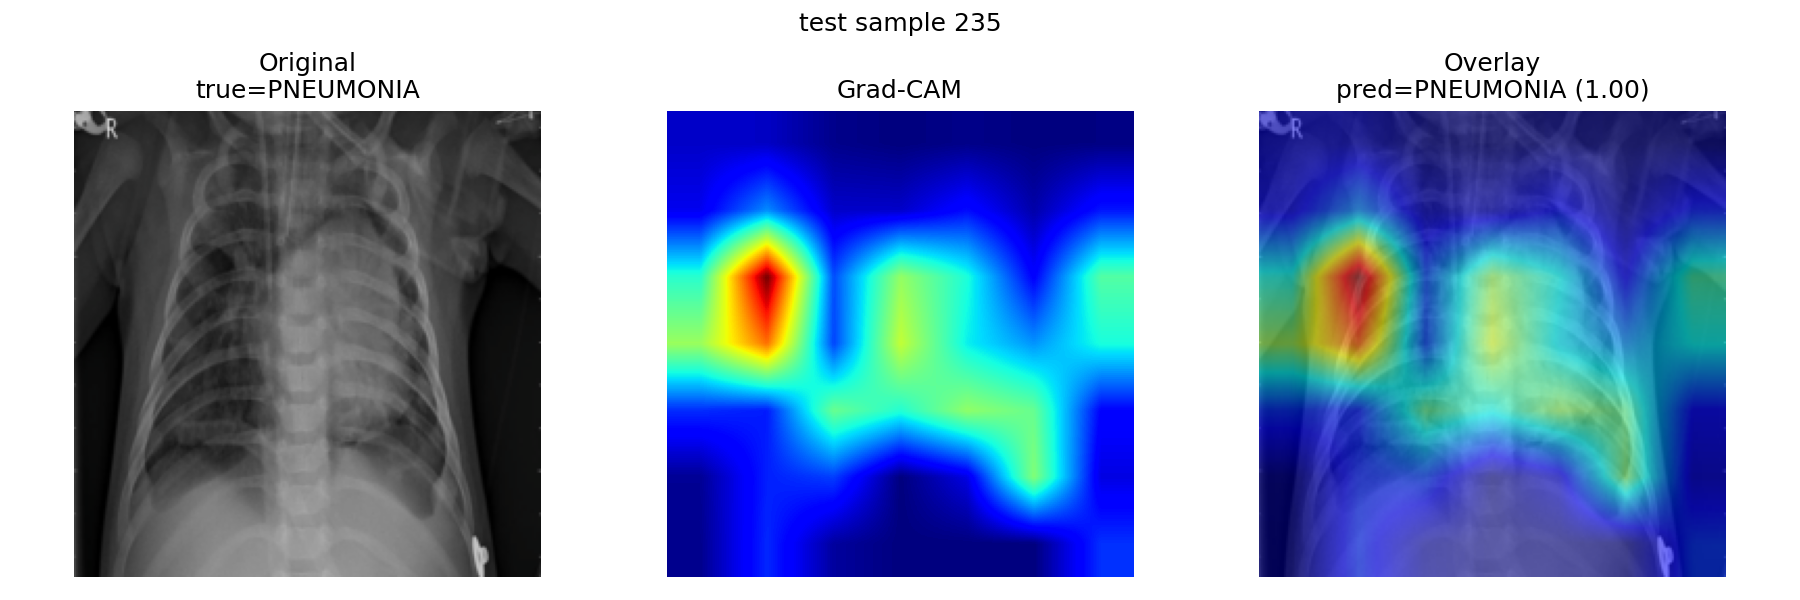

gradcam_test_05_true-PNEUMONIA_pred-PNEUMONIA.png


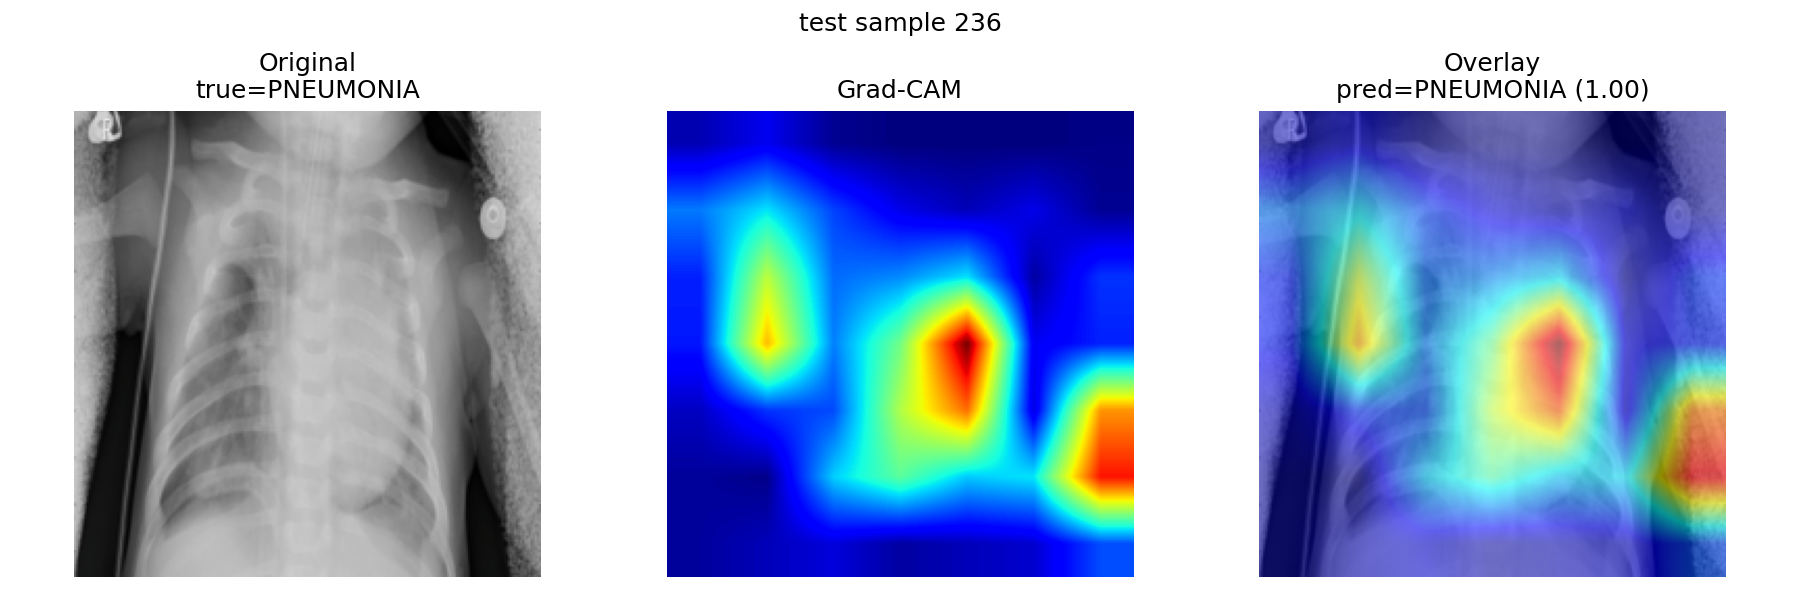

In [3]:
# Show both classes (sorted() alone puts all NORMAL filenames first)
normals = sorted(out_dir.glob("*true-NORMAL*.png"))[:3]
pneus = sorted(out_dir.glob("*true-PNEUMONIA*.png"))[:3]

print("=== NORMAL examples ===")
for path in normals:
    print(path.name)
    display(Image(filename=str(path)))

print("=== PNEUMONIA examples ===")
for path in pneus:
    print(path.name)
    display(Image(filename=str(path)))